In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title GPU Test
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# Extracting Data

In [2]:
data_path = "/content/drive/MyDrive/Intel Image Classification"

In [3]:
import os
files = os.listdir(data_path)
print(files)

['seg_val', 'seg_train']


### Spit dataset into train and val


In [ ]:
# @title OPTIONAL: No need to rerun
import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(src_root, dst_root, val_size=0.15, seed=41234):
    for class_name in os.listdir(src_root):
        class_dir = os.path.join(src_root, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = [f for f in os.listdir(class_dir) if
                  f.lower().endswith(('.png','.jpg','.jpeg'))]

        train, val = train_test_split(images, test_size=val_size,
                                           random_state=seed)
        val_ratio = val_size / (1 - val_size)
        train, val = train_test_split(train, test_size=val_size,
                                      random_state=seed)

        for split, files in [('train', train), ('val', val)]:
            split_dir = os.path.join(dst_root, split, class_name)
            os.makedirs(split_dir, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(class_dir, f),
                            os.path.join(split_dir, f))

split_dataset(data_path, "/content/drive/MyDrive/Micro_Organism_Split")

# Transforming the Data

In [4]:
import os

In [20]:
data_path = "/content/drive/MyDrive/Intel Image Classification"
train_path = os.path.join(data_path, "seg_train")
val_path = os.path.join(data_path, "seg_val")

In [21]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from collections import defaultdict
import numpy as np
# Variables
IMG_SIZE = 128 # for own CNN
BATCH = 128

# train dataset transformation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
])
# validation dataset transformation
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)


def limit_per_class(dataset, max_per_class):
    class_counts = defaultdict(int)
    indices = []
    for idx, (_, label) in enumerate(dataset.samples):
        if class_counts[label] < max_per_class:
            indices.append(idx)
            class_counts[label] += 1
    return Subset(dataset, indices)

# train_ds = limit_per_class(train_ds, max_per_class=1000)
# val_ds = limit_per_class(val_ds, max_per_class=200)


# subset_labels = [train_ds.dataset.targets[i] for i in train_ds.indices]
# class_counts = np.bincount(subset_labels)
# weights = 1.0 / class_counts[subset_labels]
# sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

class_counts = np.bincount(train_ds.targets)
weights = 1.0 / class_counts[train_ds.targets]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


In [22]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)

print(train_ds.class_to_idx)

{'forest': 0, 'sea': 1}


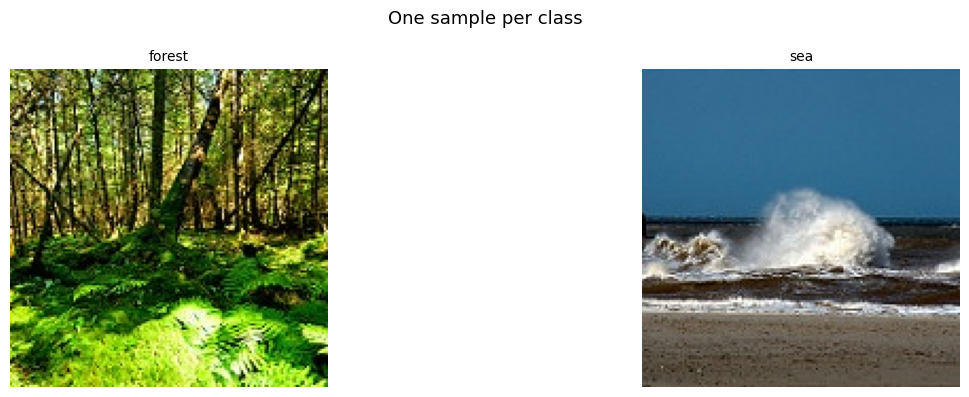

In [23]:
import matplotlib.pyplot as plt
import os
from PIL import Image

class_names = sorted(os.listdir(train_path))

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 4))

for ax, class_name in zip(axes, class_names):
    class_dir = os.path.join(train_path, class_name)
    img_file  = os.listdir(class_dir)[0]          # grab the first image
    img       = Image.open(os.path.join(class_dir, img_file)).convert('RGB')

    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis('off')

plt.suptitle('One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

# Loading the Data

In [25]:
EPOCHS = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## CNN

In [36]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),   # 224 → 112
            self._block(32,  64),   # 112 → 56
            self._block(64,  128),  # 56  → 28
            self._block(128, 256),  # 28  → 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → (B, 256, 1, 1)
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN(num_classes=len(train_ds.classes))

In [37]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR


model = CNN(num_classes=len(train_ds.classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

patience = 5
patience_counter = 0


for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    print(f"Epoch {epoch}: Training...")
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    # Val
    print(f"Epoch {epoch}: Validation...")
    model.eval()

    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    scheduler.step()
    print(f"Epoch {epoch} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")
    if epoch % 5 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0 # reset for early stopping
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Best Model: validation Accuracy = {val_acc:.4f}")

    else:
      patience_counter += 1
      print(f"No improvement. Patience: {patience_counter}/{patience}")
      if patience_counter >= patience:
          print(f"Early stopping triggered at epoch {epoch}")
          break


Epoch 1: Training...
Epoch 1: Validation...
Epoch 1 | train acc: 0.9402 | val acc: 0.9760
Best Model: validation Accuracy = 0.9760
Epoch 2: Training...
Epoch 2: Validation...
Epoch 2 | train acc: 0.9765 | val acc: 0.9589
No improvement. Patience: 1/5
Epoch 3: Training...
Epoch 3: Validation...
Epoch 3 | train acc: 0.9721 | val acc: 0.9509
No improvement. Patience: 2/5
Epoch 4: Training...
Epoch 4: Validation...
Epoch 4 | train acc: 0.9802 | val acc: 0.9790
Best Model: validation Accuracy = 0.9790
Epoch 5: Training...
Epoch 5: Validation...
Epoch 5 | train acc: 0.9811 | val acc: 0.9719
No improvement. Patience: 1/5
Epoch 6: Training...
Epoch 6: Validation...
Epoch 6 | train acc: 0.9762 | val acc: 0.9840
Best Model: validation Accuracy = 0.9840
Epoch 7: Training...
Epoch 7: Validation...
Epoch 7 | train acc: 0.9798 | val acc: 0.8747
No improvement. Patience: 1/5
Epoch 8: Training...
Epoch 8: Validation...
Epoch 8 | train acc: 0.9793 | val acc: 0.9850
Best Model: validation Accuracy = 0.9

In [38]:
# Best Model Predictions

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        probs = torch.nn.functional.softmax(out, dim=1)

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

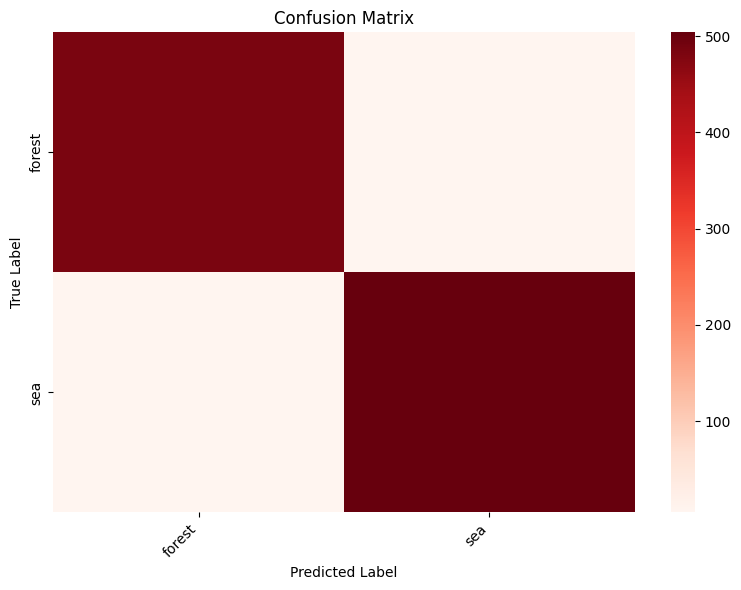

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
import pandas as pd
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names = class_names))

sensitivity_per_class = []
specificity_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fn = cm[i].sum() - tp                        # missed positives
    fp = cm[:, i].sum() - tp                     # false positives
    tn = cm.sum() - tp - fn - fp                 # true negatives

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # = recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivity_per_class.append(sensitivity)
    specificity_per_class.append(specificity)


report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report_dict).T.loc[class_names]   # only per-class rows
df['sensitivity'] = sensitivity_per_class
df['specificity'] = specificity_per_class
df = df[['precision', 'recall', 'f1-score', 'sensitivity', 'specificity', 'support']]
df['support'] = df['support'].astype(int)

print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(df.round(4).to_string())

              precision    recall  f1-score   support

      forest       0.99      0.99      0.99       488
         sea       0.99      0.99      0.99       510

    accuracy                           0.99       998
   macro avg       0.99      0.99      0.99       998
weighted avg       0.99      0.99      0.99       998

PER-CLASS METRICS
        precision  recall  f1-score  sensitivity  specificity  support
forest     0.9877  0.9898    0.9887       0.9898       0.9882      488
sea        0.9902  0.9882    0.9892       0.9882       0.9898      510


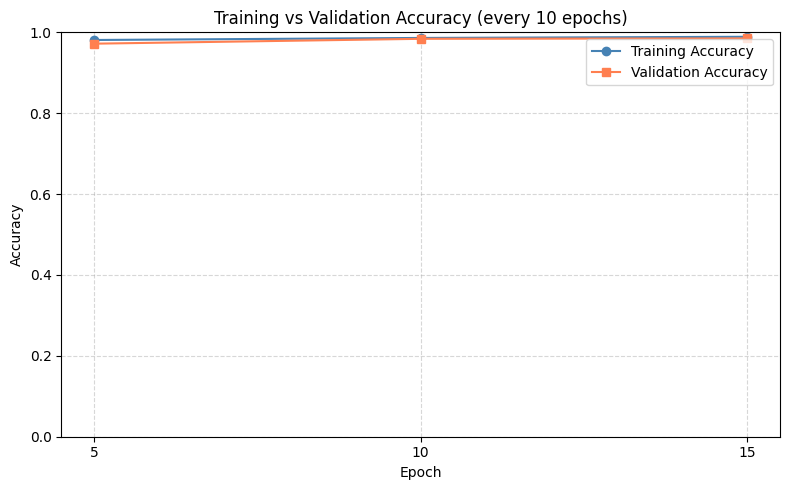

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

## CNN with Regularizer

In [42]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),   # 224 → 112
            self._block(32,  64),   # 112 → 56
            self._block(64,  128),  # 56  → 28
            self._block(128, 256),  # 28  → 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → (B, 256, 1, 1)
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN(num_classes=len(train_ds.classes))

In [43]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

model = CNN(num_classes=len(train_ds.classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

patience = 5
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    # Train
    print(f"Epoch {epoch}: Training...")
    model.train()
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    #vVal
    print(f"Epoch {epoch}: Validation...")
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    print(f"Epoch {epoch} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")
    if epoch % 5 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch:2d} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0 # reset for early stopping
        torch.save(model.state_dict(), 'best_model.pth')

    else:
      patience_counter += 1
      print(f"No improvement. Patience: {patience_counter}/{patience}")
      if patience_counter >= patience:
          print(f"Early stopping triggered at epoch {epoch}")
          break

Epoch 1: Training...
Epoch 1: Validation...
Epoch 1 | train acc: 0.9314 | val acc: 0.9719
Epoch 2: Training...
Epoch 2: Validation...
Epoch 2 | train acc: 0.9716 | val acc: 0.9820
Epoch 3: Training...
Epoch 3: Validation...
Epoch 3 | train acc: 0.9776 | val acc: 0.9669
Epoch 4: Training...
Epoch 4: Validation...
Epoch 4 | train acc: 0.9784 | val acc: 0.9800
Epoch 5: Training...
Epoch 5: Validation...
Epoch 5 | train acc: 0.9756 | val acc: 0.9709
Epoch  5 | train acc: 0.9756 | val acc: 0.9709
Epoch 6: Training...
Epoch 6: Validation...
Epoch 6 | train acc: 0.9778 | val acc: 0.9699
Epoch 7: Training...
Epoch 7: Validation...
Epoch 7 | train acc: 0.9842 | val acc: 0.9850
Epoch 8: Training...
Epoch 8: Validation...
Epoch 8 | train acc: 0.9828 | val acc: 0.9880
Epoch 9: Training...
Epoch 9: Validation...
Epoch 9 | train acc: 0.9813 | val acc: 0.9900
Epoch 10: Training...
Epoch 10: Validation...
Epoch 10 | train acc: 0.9806 | val acc: 0.9860
Epoch 10 | train acc: 0.9806 | val acc: 0.9860
Epo

In [44]:
# Best Model Predictions

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        probs = torch.nn.functional.softmax(out, dim=1)

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

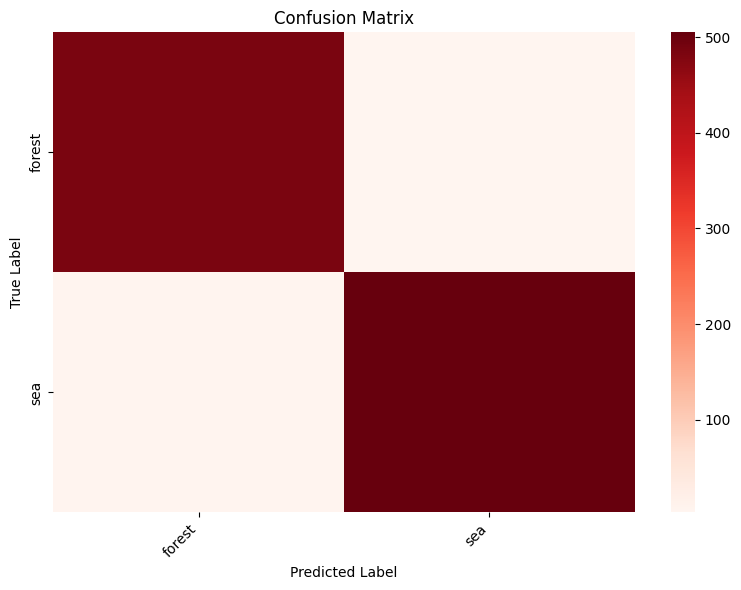

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names = class_names))

sensitivity_per_class = []
specificity_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fn = cm[i].sum() - tp                        # missed positives
    fp = cm[:, i].sum() - tp                     # false positives
    tn = cm.sum() - tp - fn - fp                 # true negatives

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # = recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivity_per_class.append(sensitivity)
    specificity_per_class.append(specificity)


report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report_dict).T.loc[class_names]   # only per-class rows
df['sensitivity'] = sensitivity_per_class
df['specificity'] = specificity_per_class
df = df[['precision', 'recall', 'f1-score', 'sensitivity', 'specificity', 'support']]
df['support'] = df['support'].astype(int)

print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(df.round(4).to_string())

              precision    recall  f1-score   support

      forest       0.99      0.99      0.99       488
         sea       0.99      0.99      0.99       510

    accuracy                           0.99       998
   macro avg       0.99      0.99      0.99       998
weighted avg       0.99      0.99      0.99       998

PER-CLASS METRICS
        precision  recall  f1-score  sensitivity  specificity  support
forest     0.9898  0.9939    0.9918       0.9939       0.9902      488
sea        0.9941  0.9902    0.9921       0.9902       0.9939      510


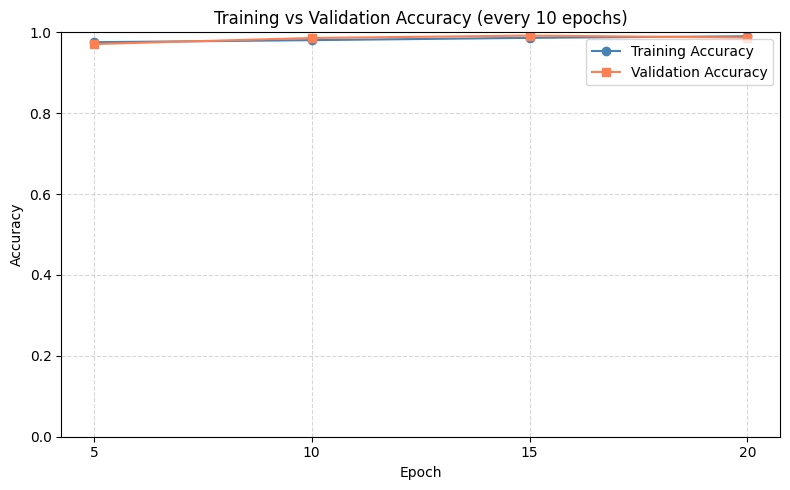

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

## Transfer Learning (Feature Transfer)

In [68]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from collections import defaultdict
import numpy as np
# Variables
IMG_SIZE = 224
BATCH = 128

# train dataset transformation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
# validation dataset transformation
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)

# Limit to 1000 images per class
# def limit_per_class(dataset, max_per_class=1000):
#     class_counts = defaultdict(int)
#     indices = []
#     for idx, (_, label) in enumerate(dataset.samples):
#         if class_counts[label] < max_per_class:
#             indices.append(idx)
#             class_counts[label] += 1
#     return Subset(dataset, indices)

# train_ds = limit_per_class(train_ds, max_per_class=1000)
# val_ds = limit_per_class(val_ds, max_per_class=200)

# Recompute weights for WeightedRandomSampler on the subset
# subset_labels = [train_ds.dataset.targets[i] for i in train_ds.indices]
# class_counts = np.bincount(subset_labels)
# weights = 1.0 / class_counts[subset_labels]
# sampler = WeightedRandomSampler(weights, num_samples=len(weights),
# replacement=True)

class_counts = np.bincount(train_ds.targets)
weights = 1.0 / class_counts[train_ds.targets]
sampler = WeightedRandomSampler(weights, num_samples=len(weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)



In [69]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)

print(train_ds.class_to_idx)

{'forest': 0, 'sea': 1}


In [70]:
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import torchvision
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models



model_ft = torchvision.models.resnet18(weights = 'IMAGENET1K_V1')
for param in model_ft.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(train_ds.classes))

model_conv = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()


optimizer_conv = optim.Adam(model_conv.fc.parameters(), lr=1e-3)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = CosineAnnealingLR(optimizer_conv, T_max=EPOCHS)

In [71]:
print(f"Number of classes in model : {len(train_ds.classes)}")
print(f"Class names                : {train_ds.classes}")
print(f"Max label in train set     : {max(train_ds.targets)}")
print(f"Min label in train set     : {min(train_ds.targets)}")
print(f"Unique labels              : {sorted(set(train_ds.targets))}")

Number of classes in model : 2
Class names                : ['forest', 'sea']
Max label in train set     : 1
Min label in train set     : 0
Unique labels              : [0, 1]


In [72]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

model = model_conv
criterion = nn.CrossEntropyLoss()
optimizer = optimizer_conv
scheduler = exp_lr_scheduler


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

patience_counter = 0
patience = 5

for epoch in range(1, EPOCHS + 1):

    # Train
    print(f"Epoch {epoch}: Training...")
    model.train()
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    #vVal
    print(f"Epoch {epoch}: Validation...")
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    print(f"Epoch {epoch} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")
    if epoch % 10 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch:2d} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

Epoch 1: Training...
Epoch 1: Validation...
Epoch 1 | train acc: 0.8730 | val acc: 0.9810
Epoch 2: Training...
Epoch 2: Validation...
Epoch 2 | train acc: 0.9850 | val acc: 0.9880
Epoch 3: Training...
Epoch 3: Validation...
Epoch 3 | train acc: 0.9886 | val acc: 0.9900
Epoch 4: Training...
Epoch 4: Validation...
Epoch 4 | train acc: 0.9875 | val acc: 0.9900
No improvement. Patience: 1/5
Epoch 5: Training...
Epoch 5: Validation...
Epoch 5 | train acc: 0.9892 | val acc: 0.9950
Epoch 6: Training...
Epoch 6: Validation...
Epoch 6 | train acc: 0.9901 | val acc: 0.9960
Epoch 7: Training...
Epoch 7: Validation...
Epoch 7 | train acc: 0.9938 | val acc: 0.9970
Epoch 8: Training...
Epoch 8: Validation...
Epoch 8 | train acc: 0.9905 | val acc: 0.9970
No improvement. Patience: 1/5
Epoch 9: Training...
Epoch 9: Validation...
Epoch 9 | train acc: 0.9927 | val acc: 0.9970
No improvement. Patience: 2/5
Epoch 10: Training...
Epoch 10: Validation...
Epoch 10 | train acc: 0.9921 | val acc: 0.9950
Epoch 1

In [73]:
# Best Model Predictions

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        probs = torch.nn.functional.softmax(out, dim=1)

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

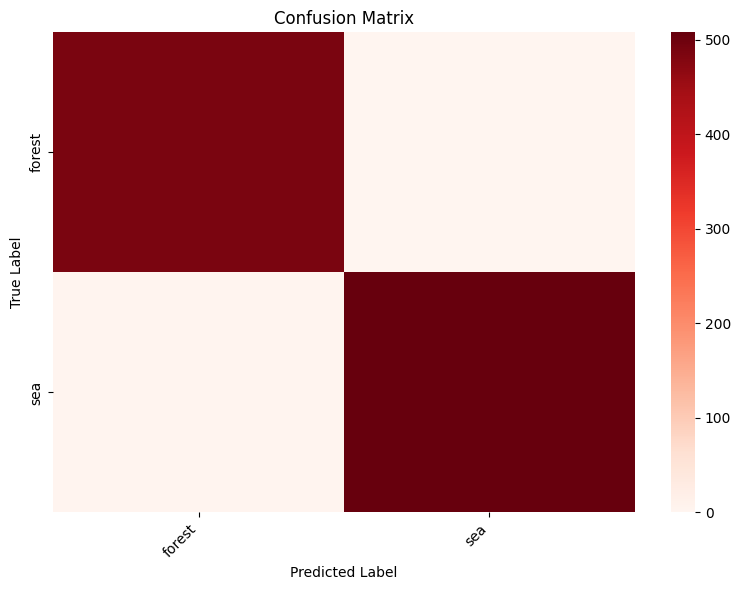

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [75]:
import pandas as pd
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names = class_names))

sensitivity_per_class = []
specificity_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fn = cm[i].sum() - tp                        # missed positives
    fp = cm[:, i].sum() - tp                     # false positives
    tn = cm.sum() - tp - fn - fp                 # true negatives

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # = recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivity_per_class.append(sensitivity)
    specificity_per_class.append(specificity)


report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report_dict).T.loc[class_names]   # only per-class rows
df['sensitivity'] = sensitivity_per_class
df['specificity'] = specificity_per_class
df = df[['precision', 'recall', 'f1-score', 'sensitivity', 'specificity', 'support']]
df['support'] = df['support'].astype(int)

print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(df.round(4).to_string())

              precision    recall  f1-score   support

      forest       1.00      1.00      1.00       488
         sea       1.00      1.00      1.00       510

    accuracy                           1.00       998
   macro avg       1.00      1.00      1.00       998
weighted avg       1.00      1.00      1.00       998

PER-CLASS METRICS
        precision  recall  f1-score  sensitivity  specificity  support
forest     0.9959  1.0000     0.998       1.0000       0.9961      488
sea        1.0000  0.9961     0.998       0.9961       1.0000      510


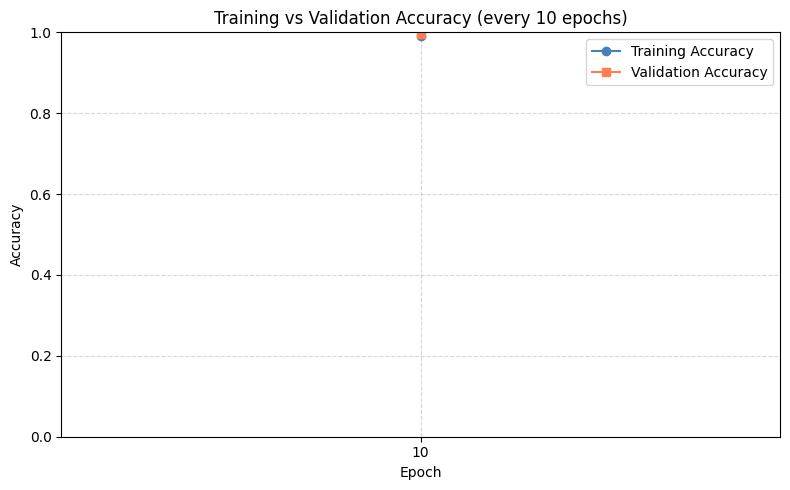

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

## Transfer Learning (Fine-tuning)

In [85]:
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import torchvision
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models



model_ft = torchvision.models.resnet18(weights = 'IMAGENET1K_V1')

# Freeze all layers
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze layer 4
for param in model_ft.layer4.parameters():
    param.requires_grad = True
#unfreeze fc
model_ft.fc = nn.Linear(model_ft.fc.in_features, len(train_ds.classes))


model_conv = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3}
])

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = CosineAnnealingLR(optimizer_conv, T_max=EPOCHS)

In [87]:
print(f"Number of classes in model : {len(train_ds.classes)}")
print(f"Class names                : {train_ds.classes}")
print(f"Max label in train set     : {max(train_ds.targets)}")
print(f"Min label in train set     : {min(train_ds.targets)}")
print(f"Unique labels              : {sorted(set(train_ds.targets))}")
print(f"Final layer  : {model_conv.fc}")

Number of classes in model : 2
Class names                : ['forest', 'sea']
Max label in train set     : 1
Min label in train set     : 0
Unique labels              : [0, 1]
Final layer  : Linear(in_features=512, out_features=2, bias=True)


In [88]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

model = model_conv
criterion = nn.CrossEntropyLoss()
optimizer = optimizer_conv
scheduler = exp_lr_scheduler


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

patience_counter = 0
patience = 5

for epoch in range(1, EPOCHS + 1):

    # Train
    print(f"Epoch {epoch}: Training...")
    model.train()
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    #vVal
    print(f"Epoch {epoch}: Validation...")
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    print(f"Epoch {epoch} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")
    if epoch % 10 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch:2d} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
      patience_counter += 1
      print(f"No improvement. Patience: {patience_counter}/{patience}")
      if patience_counter >= patience:
          print(f"Early stopping triggered at epoch {epoch}")
          break

Epoch 1: Training...
Epoch 1: Validation...
Epoch 1 | train acc: 0.9751 | val acc: 0.9970
Epoch 2: Training...
Epoch 2: Validation...
Epoch 2 | train acc: 0.9998 | val acc: 0.9990
Epoch 3: Training...
Epoch 3: Validation...
Epoch 3 | train acc: 0.9991 | val acc: 0.9990
No improvement. Patience: 1/5
Epoch 4: Training...
Epoch 4: Validation...
Epoch 4 | train acc: 0.9998 | val acc: 0.9990
No improvement. Patience: 2/5
Epoch 5: Training...
Epoch 5: Validation...
Epoch 5 | train acc: 0.9993 | val acc: 0.9990
No improvement. Patience: 3/5
Epoch 6: Training...
Epoch 6: Validation...
Epoch 6 | train acc: 1.0000 | val acc: 1.0000
Epoch 7: Training...
Epoch 7: Validation...
Epoch 7 | train acc: 1.0000 | val acc: 1.0000
No improvement. Patience: 1/5
Epoch 8: Training...
Epoch 8: Validation...
Epoch 8 | train acc: 1.0000 | val acc: 0.9990
No improvement. Patience: 2/5
Epoch 9: Training...
Epoch 9: Validation...
Epoch 9 | train acc: 1.0000 | val acc: 0.9990
No improvement. Patience: 3/5
Epoch 10: 

In [89]:
# Best Model Predictions

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        probs = torch.nn.functional.softmax(out, dim=1)

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

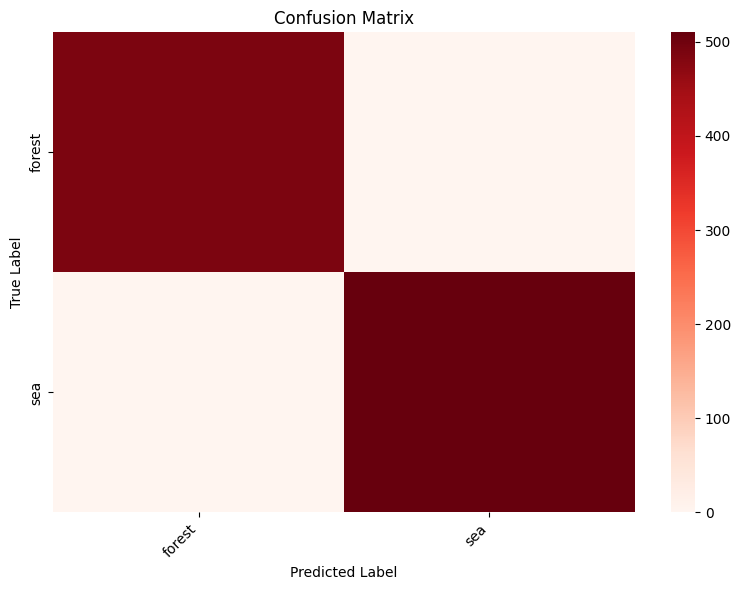

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [91]:
import pandas as pd
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names = class_names))

sensitivity_per_class = []
specificity_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fn = cm[i].sum() - tp                        # missed positives
    fp = cm[:, i].sum() - tp                     # false positives
    tn = cm.sum() - tp - fn - fp                 # true negatives

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # = recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivity_per_class.append(sensitivity)
    specificity_per_class.append(specificity)


report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report_dict).T.loc[class_names]   # only per-class rows
df['sensitivity'] = sensitivity_per_class
df['specificity'] = specificity_per_class
df = df[['precision', 'recall', 'f1-score', 'sensitivity', 'specificity', 'support']]
df['support'] = df['support'].astype(int)

print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(df.round(4).to_string())

              precision    recall  f1-score   support

      forest       1.00      1.00      1.00       488
         sea       1.00      1.00      1.00       510

    accuracy                           1.00       998
   macro avg       1.00      1.00      1.00       998
weighted avg       1.00      1.00      1.00       998

PER-CLASS METRICS
        precision  recall  f1-score  sensitivity  specificity  support
forest        1.0     1.0       1.0          1.0          1.0      488
sea           1.0     1.0       1.0          1.0          1.0      510


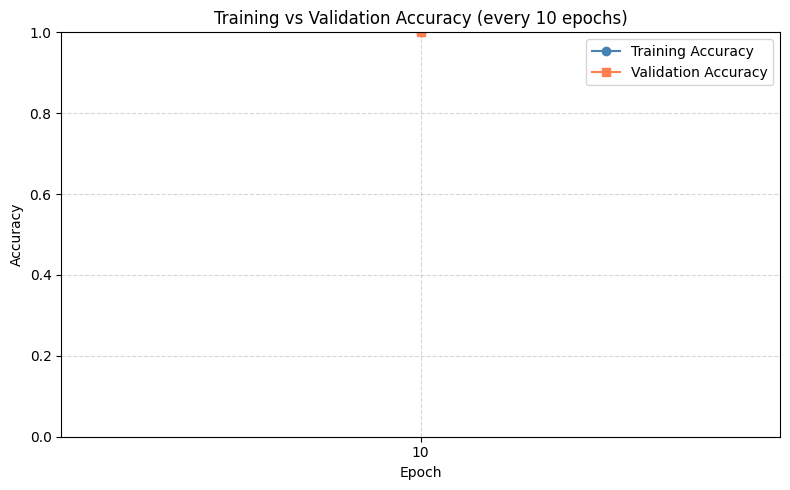

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# Analysis

### **Background of the Data:**
> So for the dataset, I used [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification). Its a dataset about natural scenes. The original dataset have about 6 categories (buildings, forest, glacier, mountain, sea, and street). Each Categories have around 2,000 datapoints. Firstly, I used all the 6 categories and consume all my credits in Google colab not even finishing 1 epochs. So, I used 3 categories. Same error persisted. Then, I tried limiting two categories to 1,000 dataset. There was an overfit. So, I used 2 categories with 2,000 datapoints each instead of limiting 3 categories with 1,000 datapoints each.

### **Data Loader:**
> For the Data Loader I used for CNN with and without regularizer, I used 128 image size to reduce computing time. In addition, I added random flipping, random rotation, and color jitter to prevent over-fitting. I tried without those random image augmentation. The model overfitted before even reaching 5 epochs. For the feature transfer, I simply changed the image size of the Data Loader to 224 because Resnet needs 224 img size.

### **CNN**
> The model validation accuray from the start is already above 97% validation accuracy. From my past experiments, it seems that data cleaning and data loading has the best effect on model accuracy. It is because when I did not add any image augmentation during data loading, there was an overfit. Based on the Confusion matrix of the CNN model, most of the True positive and True Negatives were achieved. The precision, recall, and F1 score were all 99% which was surprising to me since my early experiments with microfungi dataset did not even reached 50% accuracy. For the Plot of training vs validation accuracy, the plot is almost linear because from the first epoch of the training it is laready in 97% accuracy.

### **CNN with Regularization:**
> So for this model, I simply added weight_decay of 1e-4 in the optimizer, which is Adam. One thing I noticed here, is that the model does not immediately have high accuracy because of its regularization to overfitting. But for the dataloading of the dataset I did was enough to mitigate overfitting. Although, the accuracy of the model also reached 99% accuracy. Its confusion_matrix is similar to the CNN model. In addition, its precision, recall, and F1 score were also 99%. The plot of the vatraining vs validation accuracy is also high and almost linear.

### **Transfer Learning: Feature Transfer:**
> For Feature Transfer, I used Resnet-18 model with Image Net 1k as its weights. I freezed all the layers except the "fc layer" which is the last layer, where classification of an image to a class is done. The first epoch overfitted but it regain traction immediately after second epoch. The model reached 99 accuracy at 3 epochs which is fast and accurate. Similarly, the confusion matrix, metrics, and plot were similar to the earlier models because of 99% accuracy. The big difference here is the model achieved high accuracy at only 3 epochs.

### **Transfer Learning: Fine-Tuning:**
> For the Fine-tuning, I fine tuned the last and second to the last layer. I was contemplating on whether to fine-tuned more layers but I am thinking about the credits in google colab if I choose to fine-tune all or even half the layers. Surprisingly, the model reachged peak accuracy immediately at 2 epochs. I thought the feature-tranfer would be the fastest. It also has the highest accuracy of 99.90% accuracy compared to the earlier models. Similarly, the metrics, confusion matrix, and plot are similar to the earlier models.

# Conclusion

> In this lab activity, I was able to explore the Pytorch Library, Numpy, and even OS library in creating an Image classification Model. I was able to create CNN, and Transfer learning models. I did quite a number of experminetation to fix and fine-tune models. One of the things I learned here is the different Pros and Cons of different models. What I really learn outside of the Objectives is that clean data is the best data for training models. Even a weak model with a strong and clean data can return great results. Some of the problems I encountered during the lab activity is the credit limits in Google Colab. I think I consumed two accounts in training ugly data with little to no regard to batches and Image size. Although, the failures and mistakes I had done during this lab activity helped me understand how to treat the data and create a decent model in Pytorch. Lastly, I was able to finally wrap around on the different layers of a CNN like Convolution layer, Dropout, MAxpool, and ReLu. Overall, this lab activity challenged me and tested my mettle with data handling and model creation.